# Task 2: Exploratory Data Analysis

This notebook performs an exploratory data analysis on the `antigravity_clean.csv` dataset to understand passenger satisfaction patterns.

Dataset shape: (129880, 24)

First 5 rows:


,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,70172,Male,Loyal Customer,13,Personal Travel,Eco Plus,460,3,4,3,...,5,4,3,4,4,5,5,25,18.0,neutral or dissatisfied
1,5047,Male,disloyal Customer,25,Business travel,Business,235,3,2,3,...,1,1,5,3,1,4,1,1,6.0,neutral or dissatisfied
2,110028,Female,Loyal Customer,26,Business travel,Business,1142,2,2,2,...,5,4,3,4,4,4,5,0,0.0,satisfied
3,24026,Female,Loyal Customer,25,Business travel,Business,562,2,5,5,...,2,2,5,3,1,4,2,11,9.0,neutral or dissatisfied
4,119299,Male,Loyal Customer,61,Business travel,Business,214,3,3,3,...,3,3,4,4,3,3,3,0,0.0,satisfied



Value counts for 'satisfaction':
satisfaction
neutral or dissatisfied    0.565537
satisfied                  0.434463
Name: proportion, dtype: float64


/var/folders/f9/pszv1q012cl527b9_3j1wjt00000gp/T/ipykernel_6940/2648683247.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='satisfaction', palette='viridis')


Figure 1 saved to ../../figures/antigravity/01_satisfaction_distribution.png


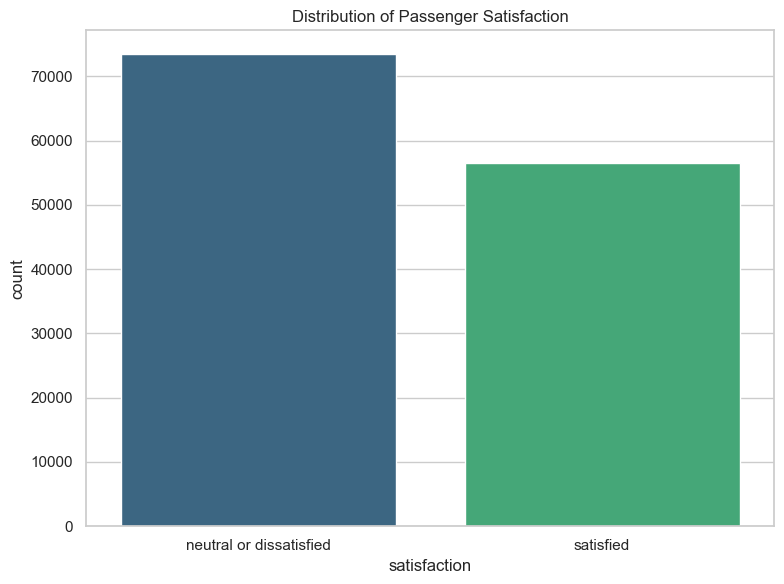

Figure 2 saved to ../../figures/antigravity/02_age_distribution_by_satisfaction.png


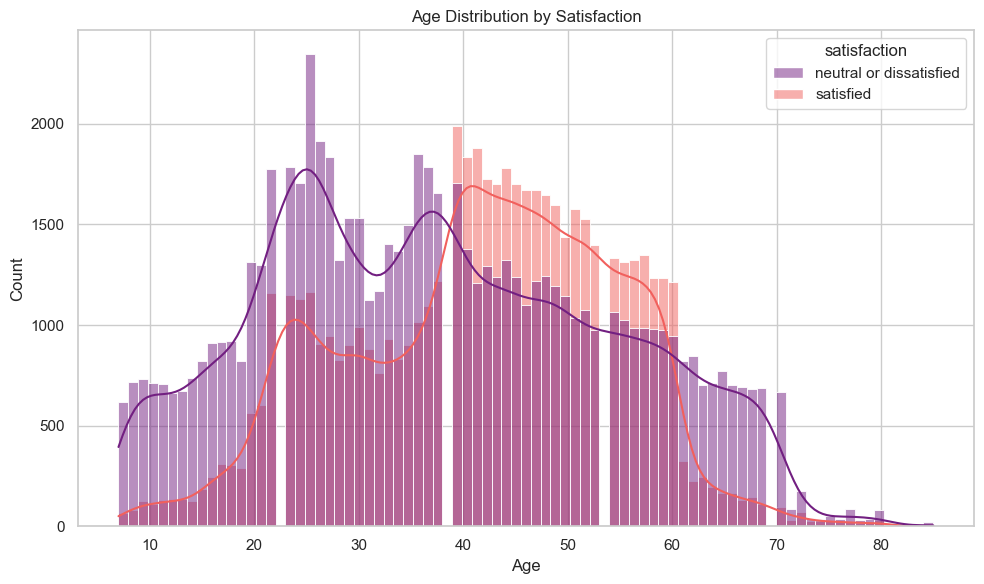

Figure 3 saved to ../../figures/antigravity/03_travel_type_vs_satisfaction.png


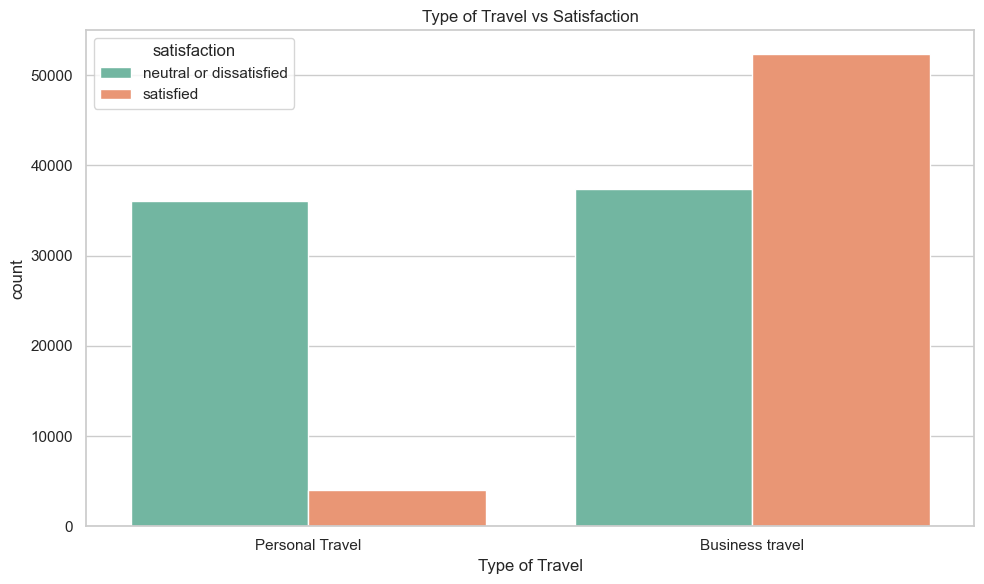

Figure 4 saved to ../../figures/antigravity/04_class_vs_satisfaction.png


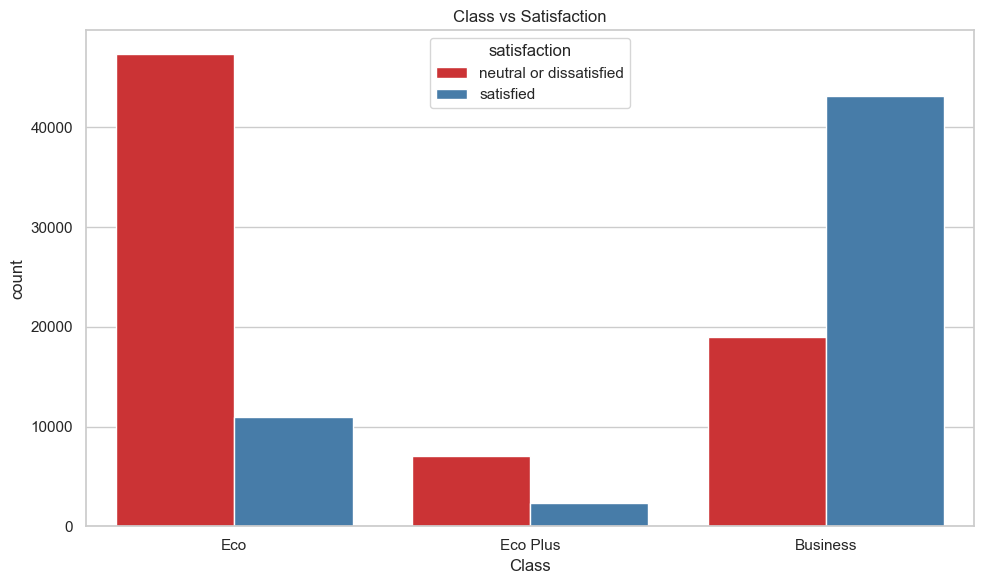

Figure 5 saved to ../../figures/antigravity/05_wifi_service_vs_satisfaction.png


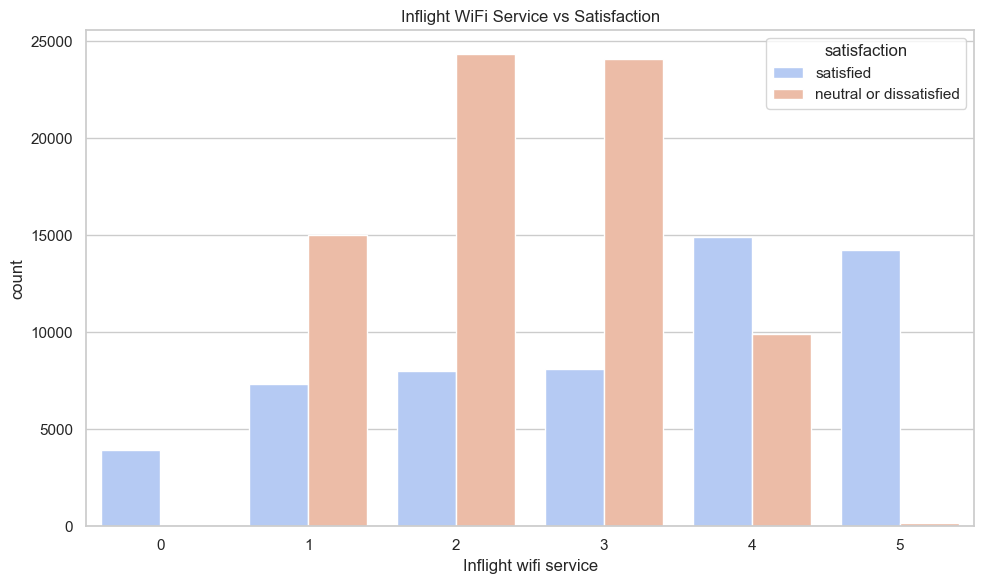

/var/folders/f9/pszv1q012cl527b9_3j1wjt00000gp/T/ipykernel_6940/2648683247.py:68: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='satisfaction', y='Flight Distance', palette='husl')


Figure 6 saved to ../../figures/antigravity/06_flight_distance_vs_satisfaction.png


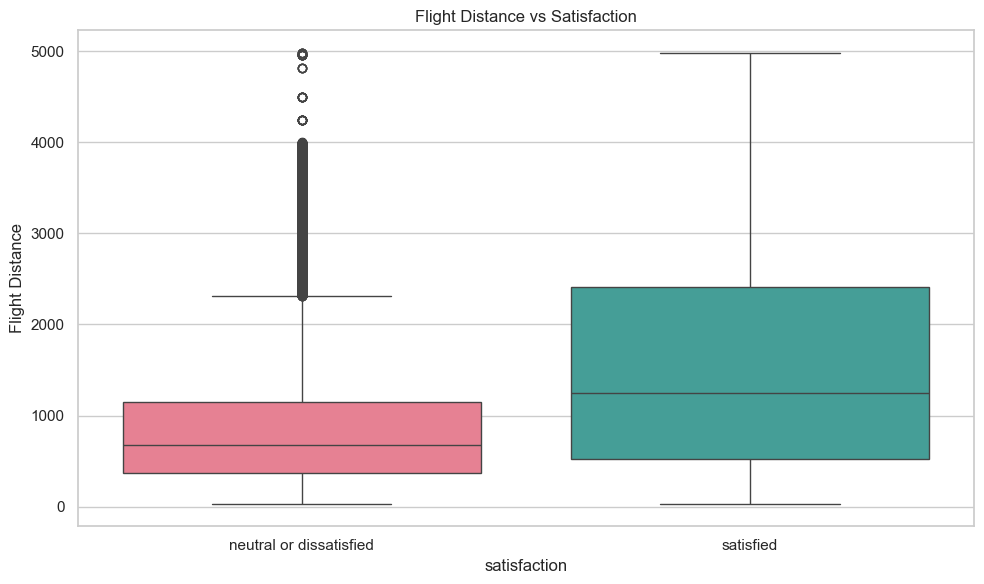

Figure 7 saved to ../../figures/antigravity/07_numeric_correlation_heatmap.png


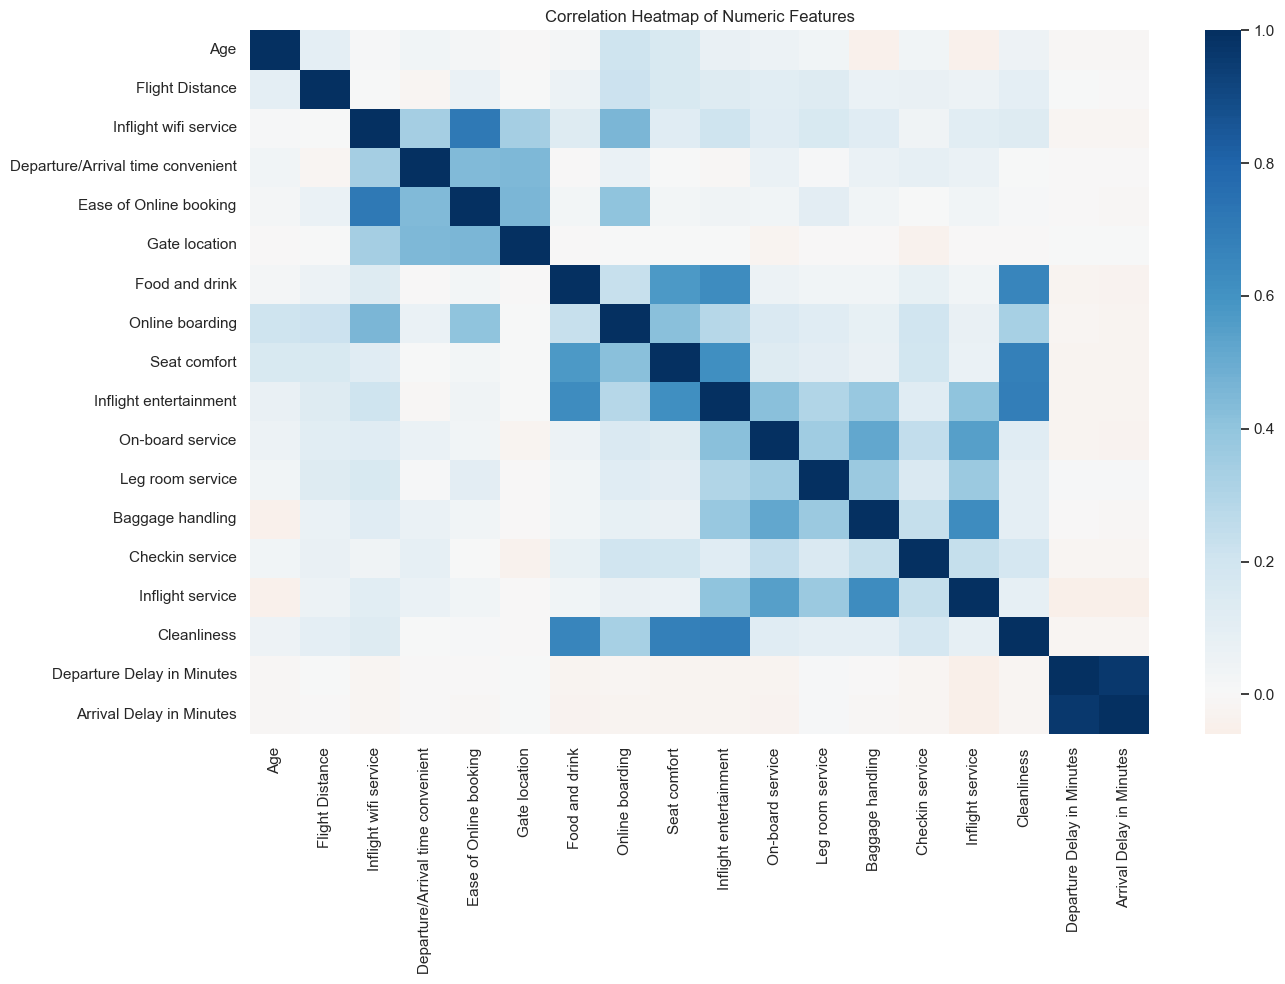


Top correlations with Satisfaction (categorical encoding for quick check):


satisfaction_binary                  1.000000
Online boarding                      0.501749
Inflight entertainment               0.398234
Seat comfort                         0.348829
On-board service                     0.322205
Leg room service                     0.312424
Cleanliness                          0.307035
Flight Distance                      0.298085
Inflight wifi service                0.283460
Baggage handling                     0.248680
Inflight service                     0.244918
Checkin service                      0.237252
Food and drink                       0.211340
Ease of Online booking               0.168877
Age                                  0.134091
id                                   0.013182
Gate location                       -0.002793
Departure Delay in Minutes          -0.050740
Departure/Arrival time convenient   -0.054270
Arrival Delay in Minutes            -0.058275
Name: satisfaction_binary, dtype: float64

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Set style
sns.set_theme(style="whitegrid")

# Create figures directory if it doesn't exist
figures_dir = '../../figures/antigravity'
os.makedirs(figures_dir, exist_ok=True)

figure_counter = 1

def save_and_show(filename, title=None):
    global figure_counter
    save_path = os.path.join(figures_dir, f"{figure_counter:02d}_{filename}.png")
    if title:
        plt.title(title)
    plt.tight_layout()
    plt.savefig(save_path)
    print(f"Figure {figure_counter} saved to {save_path}")
    plt.show()
    figure_counter += 1

# 1. Load the dataset
data_path = '../../data/processed/antigravity_clean.csv'
df = pd.read_csv(data_path)

# 2. Explore the structure of the dataset
print(f"Dataset shape: {df.shape}")
print("\nFirst 5 rows:")
display(df.head())

# 3. Identifies and reports important variables and distributions
print("\nValue counts for 'satisfaction':")
print(df['satisfaction'].value_counts(normalize=True))

# 4. Generates a maximum of 7 visualisations

# Visualization 1: Target distribution
plt.figure(figsize=(8, 6))
sns.countplot(data=df, x='satisfaction', palette='viridis')
save_and_show("satisfaction_distribution", "Distribution of Passenger Satisfaction")

# Visualization 2: Age distribution by satisfaction
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='Age', hue='satisfaction', kde=True, palette='magma')
save_and_show("age_distribution_by_satisfaction", "Age Distribution by Satisfaction")

# Visualization 3: Type of Travel vs Satisfaction
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='Type of Travel', hue='satisfaction', palette='Set2')
save_and_show("travel_type_vs_satisfaction", "Type of Travel vs Satisfaction")

# Visualization 4: Class vs Satisfaction
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='Class', hue='satisfaction', order=['Eco', 'Eco Plus', 'Business'], palette='Set1')
save_and_show("class_vs_satisfaction", "Class vs Satisfaction")

# Visualization 5: Inflight wifi service vs Satisfaction
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='Inflight wifi service', hue='satisfaction', palette='coolwarm')
save_and_show("wifi_service_vs_satisfaction", "Inflight WiFi Service vs Satisfaction")

# Visualization 6: Flight Distance vs Satisfaction
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='satisfaction', y='Flight Distance', palette='husl')
save_and_show("flight_distance_vs_satisfaction", "Flight Distance vs Satisfaction")

# Visualization 7: Correlation heatmap of numeric features
plt.figure(figsize=(14, 10))
numeric_df = df.select_dtypes(include=['int64', 'float64']).drop(columns=['id'], errors='ignore')
sns.heatmap(numeric_df.corr(), annot=False, cmap='RdBu', center=0)
save_and_show("numeric_correlation_heatmap", "Correlation Heatmap of Numeric Features")

# 5. Highlights any interesting patterns or potential predictive features
print("\nTop correlations with Satisfaction (categorical encoding for quick check):")
df_encoded = df.copy()
df_encoded['satisfaction_binary'] = (df['satisfaction'] == 'satisfied').astype(int)
correlations = df_encoded.select_dtypes(include=['number']).corr()['satisfaction_binary'].sort_values(ascending=False)
display(correlations)